In [1]:
from ezphot.utils import DataBrowser
from ezphot.methods import MaskGenerator

In [ ]:
databrowser = DataBrowser('scidata')
databrowser.objname = 'T00528'
databrowser.filter = 'r'
target_imgset = databrowser.search('*100.fits', 'science')
target_imglist = target_imgset.target_images

[INFO] Found 54 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/r/*100.fits'


Loading Science Images: 100%|██████████| 54/54 [00:00<00:00, 96.68it/s] 


[INFO] Found 36 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00464/*/r/*100.fits'


Loading Science Images: 100%|██████████| 36/36 [00:00<00:00, 110.28it/s]


[INFO] Found 39 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00465/*/r/*100.fits'


...

Loading Science Images: 100%|██████████| 12/12 [00:00<00:00, 71.20it/s]


[INFO] Found 12 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00596/*/r/*100.fits'


Loading Science Images: 100%|██████████| 12/12 [00:00<00:00, 64.06it/s]


[INFO] Found 6 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00405/*/r/*100.fits'


Loading Science Images: 100%|██████████| 6/6 [00:00<00:00, 37.67it/s]


(<Figure size 800x600 with 2 Axes>,
 <WCSAxes: title={'center': 'calib_7DT16_T00528_20250902_074905_r_100.fits'}>)

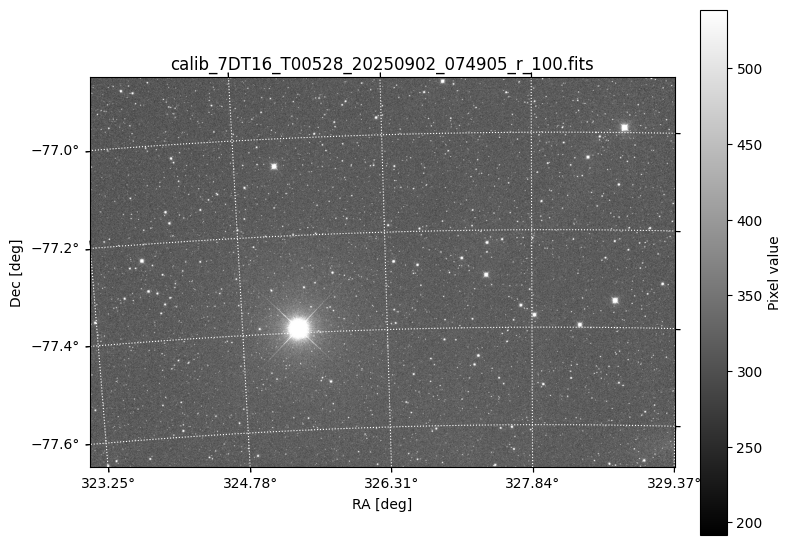

In [3]:
target_img = target_imglist[0]
target_img.show('coord')

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'True'}>)

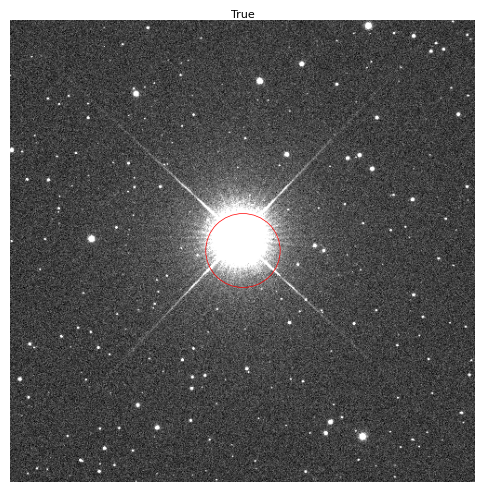

In [10]:
target_img.show_position(325.38, -77.4, 'coord', 4, 1000)

In [4]:
visualize = False
verbose = False
save_fig = True

In [ ]:
masking = MaskGenerator()
for target_img in target_imglist:
    target_srcmask = None
    # target_srcmask = masking.mask_circle(
    #     target_img = target_img, 
    #     target_mask = None,
    #     x_position = 325.37,
    #     y_position = -77.39,
    #     radius_arcsec = 500,
    #     unit = 'deg',
    #     save = False,
    #     verbose = True,
    #     visualize = True,
    #     save_fig = False
    # )
    target_srcmask = target_img.calculate_sourcemask(
        target_srcmask = target_srcmask,
        save = True,
        verbose = verbose,
        visualize = visualize,
        save_fig = save_fig
    )
    target_img.clear()
    target_srcmask.clear()

In [ ]:
for target_img in target_imglist:
    target_bkg = target_img.calculate_bkg(
        target_srcmask = target_img.sourcemask,
        target_ivpmask = None,
        is_2D_bkg = True,
        box_size = 128,
        filter_size = 3,
        save = True,
        verbose = verbose,
        visualize = visualize,
        save_fig = save_fig
    )
    target_img.clear()
    target_bkg.clear()
    

In [9]:
from ezphot.methods import Preprocess
preprocessor = Preprocess()
for target_img in target_imglist:
    from ezphot.imageobjects import CalibrationImage
    bias_tbl = preprocessor.get_masterframe_from_image(
        target_img = target_img,
        imagetyp = 'bias',
        max_days = 100
    )
    dark_tbl = preprocessor.get_masterframe_from_image(
        target_img = target_img,
        imagetyp = 'dark',
        max_days = 100
    )
    flat_tbl = preprocessor.get_masterframe_from_image(
        target_img = target_img,
        imagetyp = 'flat',
        max_days = 100
    )
    mbias = CalibrationImage(bias_tbl[0]['file'])
    mdark = CalibrationImage(dark_tbl[0]['file'])
    mflat = CalibrationImage(flat_tbl[0]['file'])
    target_bkgrms = target_img.calculate_bkgrms_from_propagation(
        target_bkg = target_img.bkgmap,
        mbias = mbias,
        mdark = mdark,
        mflat = mflat,
        mflaterr = None,
        ncombine = 1,
        readout_noise = target_img.telinfo['readnoise'],
        save = True,
        verbose = verbose,
        visualize = visualize,
        save_fig = save_fig
    )